150


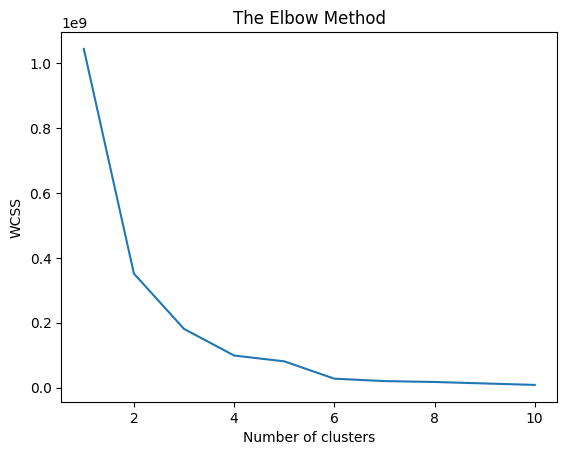

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dt = pd.read_csv('country_energy_emissions.csv')

#dropna→欠損値（NaN）を含む行や列を削除する関数
#subset→どの列を基準に欠損をチェックするか」を指定する

dt = dt.dropna(subset=[
    "Carbon dioxide emissions per capita (CO2 equivalent)",
    "Primary energy supply per capita (oil equivalent)"
])
#この2つの列のどちらかに NaN があったらその行（国）を削除する

print(len(dt))

X = dt.iloc[:, 1:3].values

from sklearn.cluster import KMeans

#WCSS(各クラスタ内のバラつきの合計)を入れていく空のリストを作る。
wcss = []
#クラスタ数 i を 1〜10 まで変えて試すためのループをつくる
"""
KMeansモデルを作る。
n_clusters=i：クラスタ数を i 個にする
init='k-means++'：初期の中心点の選び方（賢いやり方）。結果が安定しやすい
random_state=42：乱数を固定して、毎回ほぼ同じ結果になるようにする（再現性）
"""
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    #inertia_ →各データ点と、その属するクラスタ中心との距離²の合計
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


In [5]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
"""
y_kmeans の中身
例：
[0, 2, 1, 0, 0, 2, 1, ...]
これは
0番クラスタ
1番クラスタ
2番クラスタ
のどれに属するかを示す番号。
"""

y_kmeans = kmeans.fit_predict(X)
"""
fit(X)
→ データを使ってクラスタを学習
predict(X)
→ 各データがどのクラスタかを決める
fit_predict() はその両方を一気にやる便利関数。
"""
kmeans.get_params()
#このモデルの「設定一覧」を見るための関数

y_kmeans

array([0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 1, 0, 0, 0, 1, 2, 0, 0, 2, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2,
       2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2], dtype=int32)

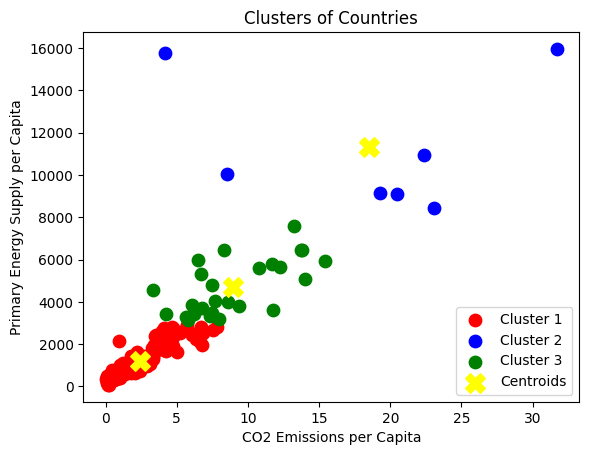

In [6]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1],
            s=80, c='red', label='Cluster 1')

"""
 X[y_kmeans == 0, 0]
y_kmeans == 0
→ クラスタ0に属するデータだけ取り出す
,0
→ 1列目（CO2）
 「クラスタ0のCO2」

X[y_kmeans == 0, 1]
同じクラスタ0
,1
→ 2列目（Energy）
「クラスタ0のEnergy」

つまり：

👉 クラスタ0の国だけを
👉 (CO2, Energy) の位置に
👉 赤い点で描いている
"""

plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1],
            s=80, c='blue', label='Cluster 2')

plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1],
            s=80, c='green', label='Cluster 3')

# 各クラスタの中心点を黄色の×で描く
#kmeans.cluster_centers_　➡各クラスタの“真ん中の座標”
#s=200 →点を大きくして目立たせている
#marker='X' →丸ではなく「×」にしている
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', marker='X', label='Centroids')

plt.title('Clusters of Countries')
plt.xlabel('CO2 Emissions per Capita')
plt.ylabel('Primary Energy Supply per Capita')

plt.legend()
plt.show()

"""
各国の一人当たりエネルギー供給量とCO2排出量を用いて、K-meansによるクラスタリングモデルを構築した。
欠損値処理や標準化を行い、エルボー法でクラスタ数を自分で判断するという工程を通じて、作成者の仮説や勘が重要であることを学んだ。
特に教師なし学習では正解がないため、どのクラスタ数が適切かをグラフから読み取る力が求められる点が新鮮だった。
可視化の結果、エネルギー消費量とCO2排出量には概ね正の相関が見られ、低・中消費国では比例関係が確認できた。
一方で高エネルギー消費国ではCO2排出量にばらつきがあり、エネルギー構成の違いが影響している可能性を感じた。
"""